# Differential Privacy

Suppose a hospital publishes "the average age of patients with disease X is
47.3." If you know everyone in the dataset except one person, and you know
the average changes to 47.1 once that one person is removed, you can back
out that person's age *exactly* — even though the hospital never published
any individual's record. Releasing *any* function of a dataset, however
innocuous it looks, can leak individual-level information once an adversary
brings in outside knowledge. This is not a hypothetical: it is essentially
what happened when researchers re-identified individuals in the "anonymized"
Netflix Prize dataset and the Massachusetts hospital discharge dataset by
linking aggregate/de-identified released data with public side information.

**Differential privacy (DP)** is a mathematically precise definition of
"this computation does not leak much about any single individual," together
with a toolbox of mechanisms that provably satisfy it. Unlike ad hoc
approaches (removing names, aggregating into buckets, k-anonymity), DP gives
a quantitative, composable privacy guarantee that holds *no matter what
auxiliary information an adversary has* — including information from every
other release ever made from overlapping data.

This tutorial:

- States the formal $(\varepsilon, \delta)$-differential privacy definition
  and explains exactly what guarantee it provides and against what threat
  model.
- Derives the **Laplace mechanism** from scratch, including a full proof
  that it achieves pure $\varepsilon$-DP.
- Covers the **Gaussian mechanism** and why $(\varepsilon,\delta)$-DP (as
  opposed to pure $\varepsilon$-DP) is often the practical choice.
- States and justifies the **composition theorems** that make "privacy
  budget" a real, depletable resource — the concept underlying **DP-SGD**,
  the standard way to train differentially private ML models.
- Implements the Laplace mechanism by hand on the real UCI Adult Census
  Income dataset to empirically show the accuracy/privacy tradeoff as a
  function of $\varepsilon$.
- Trains a real differentially private classifier with `diffprivlib`'s
  `LogisticRegression` on the same data, at several privacy budgets, and
  compares it against a non-private `scikit-learn` baseline.
- Closes with a **Limitations & debates** section covering the real,
  contested epsilon choices in deployed systems (the US Census Bureau's
  2020 DP disclosure system), the documented tension between DP and
  fairness, and the practical gap between the clean mechanisms taught here
  and real-world DP system deployments.

By the end you'll be able to state the formal DP guarantee precisely, prove
the Laplace mechanism satisfies it, explain why repeated queries deplete a
privacy budget, and reason quantitatively about the privacy/accuracy
tradeoff on a real dataset and a real DP model.

## 1. Theory

### 1.1 Neighboring datasets and the formal definition

Let $D$ be a dataset consisting of $n$ records, one per individual. Two
datasets $D$ and $D'$ are **neighboring** (written $D \sim D'$) if they
differ in exactly one individual's record and agree everywhere else. There
are two common conventions for what "differ" means:

- **Bounded DP**: $D$ and $D'$ have the same size $n$, and exactly one
  record's *value* is changed (e.g. one person's income label is different).
  This is the convention we use throughout this tutorial.
- **Unbounded DP**: $D'$ is obtained from $D$ by adding or removing one
  record ($|D'| = |D| \pm 1$).

Both formalize the same intuition: $D$ and $D'$ represent "the world with
this one person's data" vs. "the world without it (or with a different
value for it)." A randomized mechanism $M$ that maps a dataset to some
output (a number, a vector, a trained model, ...) is **differentially
private** if it behaves *almost identically* on any two such neighbors.

> **Definition (($\varepsilon$, $\delta$)-Differential Privacy).** A
> randomized mechanism $M: \mathcal{D} \to \mathcal{R}$ satisfies
> $(\varepsilon, \delta)$-differential privacy if for all neighboring
> datasets $D \sim D'$ and for all measurable output sets $S \subseteq
> \mathcal{R}$:
> $$P(M(D) \in S) \le e^{\varepsilon} \cdot P(M(D') \in S) + \delta$$

When $\delta = 0$ this is called **pure $\varepsilon$-differential privacy**;
we write $M(D) \approx_\varepsilon M(D')$. Smaller $\varepsilon$ means a
tighter bound, i.e. stronger privacy — the two neighboring worlds' output
distributions are forced to look almost identical. $\delta > 0$ allows a
small "failure probability" — an event of probability at most $\delta$
where the guarantee can be violated entirely (in practice $\delta$ is set
to something cryptographically small, e.g. $\delta \ll 1/n$, so it is not a
meaningful loophole for a determined adversary at realistic sample sizes).

**Why this is a worst-case guarantee, and why that matters.** The
definition quantifies over *all* neighboring $D, D'$ and *all* measurable
$S$ — not just "typical" datasets or "likely" outputs. This has a crucial
consequence: whatever the mechanism does, the *ratio* of how likely any
particular output is under $D$ versus under $D'$ is bounded by $e^\varepsilon$,
**regardless of what side information an adversary already has** about the
other $n-1$ records. An adversary who already knows every other person in
the dataset, and is trying to determine whether a specific target
individual's record is $D$'s version or $D'$'s version by observing $M$'s
output, cannot update their belief by more than a factor of $e^{\varepsilon}$
(in odds), no matter what prior they started with. This is what makes DP
different from "we anonymized/aggregated the data" — those approaches
provide no guarantee once the adversary has *any* auxiliary information, and
in practice adversaries almost always have some.

Two more properties worth stating up front because they explain why DP
mechanisms look the way they do:

- **Post-processing immunity.** If $M$ is $(\varepsilon,\delta)$-DP and $g$
  is any function (possibly randomized) that does not look at $D$ again,
  then $g(M(D))$ is also $(\varepsilon,\delta)$-DP. You cannot un-DP a
  private output by computing on it further — this is what licenses
  publishing DP statistics and then letting anyone do arbitrary downstream
  analysis on them without a fresh privacy cost.
- **Group privacy.** The same definition, applied to datasets differing in
  $k$ records instead of one, degrades gracefully to $k\varepsilon$-DP (by
  a triangle-inequality argument over a chain of $k$ single-record
  neighbors) — so DP protects small groups too, just with a proportionally
  weaker guarantee.

### 1.2 Global sensitivity and the Laplace mechanism

To make a numeric query private, we need to know how much a single record
can possibly change its true answer.

> **Definition (Global sensitivity).** For a real-valued (or vector-valued)
> query function $f: \mathcal{D} \to \mathbb{R}^k$, the global sensitivity
> is
> $$\Delta f = \max_{D \sim D'} \lVert f(D) - f(D') \rVert_1$$
> the largest possible change in $f$'s true answer between any two
> neighboring datasets.

For example, a *count* query ("how many people earn >\$50k") has sensitivity
$\Delta f = 1$ under bounded DP (changing one person's label changes the
count by at most 1). A *mean/proportion* query over a fixed-size dataset of
$n$ records has sensitivity $\Delta f = 1/n$ (changing one binary label
changes the sum by at most 1, and the mean is that sum divided by the fixed
$n$).

> **Definition (Laplace mechanism).** Given a query $f$ with sensitivity
> $\Delta f$, the Laplace mechanism releases
> $$M(D) = f(D) + \mathrm{Lap}(\Delta f / \varepsilon)$$
> where $\mathrm{Lap}(b)$ denotes a draw from the Laplace distribution with
> location 0 and scale $b$, density $p(x) = \frac{1}{2b} e^{-|x|/b}$.

**Claim.** The Laplace mechanism satisfies pure $\varepsilon$-differential
privacy.

**Proof.** Fix any neighboring $D \sim D'$ and let $t = f(D)$, $t' = f(D')$,
so $|t - t'| \le \Delta f$ by the definition of sensitivity. Let $p_D(z)$
denote the density of $M(D)$ at output value $z$, i.e. the density of
$t + \mathrm{Lap}(\Delta f/\varepsilon)$ evaluated at $z$, which is
$\frac{\varepsilon}{2\Delta f}\exp\!\left(-\frac{\varepsilon}{\Delta f}|z - t|\right)$
(and analogously $p_{D'}(z)$ with $t'$ in place of $t$). For any output $z$:

$$
\frac{p_D(z)}{p_{D'}(z)}
= \exp\!\left(\frac{\varepsilon}{\Delta f}\Big(|z - t'| - |z - t|\Big)\right)
\le \exp\!\left(\frac{\varepsilon}{\Delta f}\,|t - t'|\right)
\le \exp\!\left(\frac{\varepsilon}{\Delta f}\cdot \Delta f\right)
= e^{\varepsilon}
$$

where the first inequality is the reverse triangle inequality,
$|z-t'| - |z-t| \le |t - t'|$, and the second uses $|t-t'| \le \Delta f$.
By symmetry (swapping the roles of $D, D'$) the same bound holds for
$p_{D'}(z)/p_D(z)$, so $e^{-\varepsilon} \le p_D(z)/p_{D'}(z) \le e^{\varepsilon}$
for every $z$. Integrating this pointwise density ratio bound over any
measurable set $S$ gives $P(M(D)\in S) \le e^{\varepsilon} P(M(D') \in S)$,
which is exactly $(\varepsilon, 0)$-DP. $\blacksquare$

This is a genuinely clean proof: the whole mechanism works because the
Laplace density's log-ratio between two points is *exactly* proportional to
the distance between those points, so shifting the center by at most
$\Delta f$ can only move the log-density-ratio by at most
$\varepsilon = (\Delta f / \Delta f) \cdot \varepsilon$ — the scale
parameter is chosen precisely to cancel $\Delta f$ and leave $\varepsilon$.

### 1.3 The Gaussian mechanism

Adding i.i.d. Gaussian instead of Laplace noise, calibrated to the query's
$\ell_2$ sensitivity $\Delta_2 f = \max_{D\sim D'}\lVert f(D)-f(D')\rVert_2$,
gives the **Gaussian mechanism**:

$$M(D) = f(D) + \mathcal{N}(0, \sigma^2), \qquad
\sigma \ge \frac{\Delta_2 f\, \sqrt{2\ln(1.25/\delta)}}{\varepsilon}$$

which satisfies $(\varepsilon, \delta)$-DP for $\delta > 0$ (the Gaussian's
tails are lighter than Laplace's but never vanish, so it cannot achieve
*pure* $\varepsilon$-DP with $\delta=0$ — there is always a nonzero
probability, bounded by $\delta$, that the density ratio bound fails).
Why bother with a mechanism that only gets $(\varepsilon,\delta)$ instead of
pure $\varepsilon$? Two practical reasons: (1) Gaussian noise composes more
tightly than Laplace noise under many repeated queries via *moments
accountant* / *Rényi DP* style composition (used in DP-SGD, Section 1.5),
giving a much smaller total privacy cost for the same per-query noise level
when a mechanism is invoked thousands of times, and (2) it is the natural
choice when sensitivity is measured in $\ell_2$ (e.g. gradient vectors in
ML training), where Gaussian noise is rotationally symmetric and Laplace is
not.

### 1.4 Composition: why a privacy budget depletes

Real analyses rarely ask just one query. What happens to the guarantee
when you run several DP mechanisms on the *same* underlying data?

> **Theorem (Sequential composition).** If $M_1, \dots, M_k$ are mechanisms
> where $M_i$ is $(\varepsilon_i, \delta_i)$-DP, then releasing all of
> $M_1(D), \dots, M_k(D)$ together (as a single combined mechanism) is
> $\left(\sum_{i=1}^k \varepsilon_i,\ \sum_{i=1}^k \delta_i\right)$-DP.

**Why (sketch).** For pure $\varepsilon_i$-DP mechanisms, fix neighboring
$D \sim D'$ and any outputs $(z_1,\dots,z_k)$. If each $M_i$ is run
independently, the joint density factors, and each factor's density ratio
between $D$ and $D'$ is bounded by $e^{\varepsilon_i}$ (this is exactly the
per-mechanism DP guarantee). Multiplying the $k$ per-mechanism ratio bounds
gives a joint ratio bounded by $e^{\varepsilon_1}\cdots e^{\varepsilon_k} =
e^{\sum_i \varepsilon_i}$, which is precisely the definition of
$\left(\sum_i \varepsilon_i\right)$-DP. (The general $(\varepsilon,\delta)$
case follows the same multiplicative argument with a union bound absorbing
the $\delta_i$ failure probabilities.)

> **Theorem (Parallel composition, informal).** If $M_1,\dots,M_k$ are each
> $\varepsilon$-DP and are applied to **disjoint** subsets of $D$ (no
> individual's record is touched by more than one $M_i$), the combined
> release is only $\varepsilon$-DP overall, not $k\varepsilon$ — because no
> single individual's neighboring-dataset change can affect more than one
> of the $M_i$'s outputs.

Sequential composition is the one that matters for this tutorial's central
practical point: **every time you run a DP query against the *same*
individuals' data, you pay privacy budget, and that budget adds up.** A
data curator who commits to a total budget of $\varepsilon_{\text{total}}$
and then answers $k$ queries each at $\varepsilon_{\text{total}}/k$ (an
even *split*, one of many valid allocation strategies) sees the *per-query*
noise grow with $k$ (since each query's Laplace scale is
$\Delta f / (\varepsilon_{\text{total}}/k) = k\,\Delta f/\varepsilon_{\text{total}}$)
— accuracy degrades the more questions you ask. This is why practical DP
systems need **privacy accounting**: explicit bookkeeping of how much
budget every past and pending query has consumed, so the curator can refuse
or stop answering once $\varepsilon_{\text{total}}$ is exhausted.

### 1.5 DP-SGD: composition meets machine learning

Training a model touches every training example, often across many
gradient steps — exactly the repeated-query setting composition warns
about. **DP-SGD** (Abadi et al., 2016) makes ordinary mini-batch SGD
differentially private with two changes applied at *every* training step
$t$:

1. **Per-example gradient clipping.** Compute the per-example gradient
   $g_i = \nabla_\theta \mathcal{L}(\theta_t; x_i)$ for each example $i$ in
   the minibatch, then clip its $\ell_2$ norm to a fixed bound $C$:
   $\bar g_i = g_i / \max(1, \lVert g_i \rVert_2 / C)$. This caps any single
   example's influence on the update, giving the gradient sum a known,
   bounded $\ell_2$ sensitivity of $C$ — exactly the quantity the Gaussian
   mechanism needs.
2. **Noise addition.** Add Gaussian noise to the clipped, summed gradient
   before applying the update:
   $$\tilde g_t = \frac{1}{|B_t|}\left(\sum_{i \in B_t} \bar g_i + \mathcal{N}(0, \sigma^2 C^2 I)\right)$$
   and step $\theta_{t+1} = \theta_t - \eta\, \tilde g_t$.

Each step is a Gaussian-mechanism release on the (clipped) gradient, so it
consumes some $(\varepsilon_t, \delta_t)$ of privacy budget. Training for
$T$ steps would naively cost $\sum_t \varepsilon_t$ by sequential
composition — but because each step only touches a random subsample of the
data (privacy amplification by subsampling) and the mechanism is Gaussian
(tighter composition via Rényi DP / the moments accountant), the *actual*
total cost after careful accounting is much smaller than the naive sum,
which is precisely why DP-SGD is practical at all for training over many
epochs. We do not implement a full DP-SGD training loop here (it requires a
deep learning framework's per-example gradient support, e.g. Opacus for
PyTorch) — the goal of this section is the conceptual bridge from "the
composition theorem" to "why real DP model training needs an accountant,"
which the classifier we do train below (`diffprivlib`'s DP logistic
regression, via *objective perturbation* rather than DP-SGD, another valid
route to a DP classifier) illustrates empirically in Section 3.2.

## 2. Visuals

Before touching real data, let's *see* the Laplace mechanism proof from
Section 1.2 in action: two neighboring "worlds" with true answers one unit
apart, and the noisy output distributions the mechanism produces at a few
different $\varepsilon$ values. As $\varepsilon$ shrinks, the two
distributions become harder to tell apart — which is exactly the privacy
guarantee (a small density-ratio bound $e^\varepsilon$) made visible.

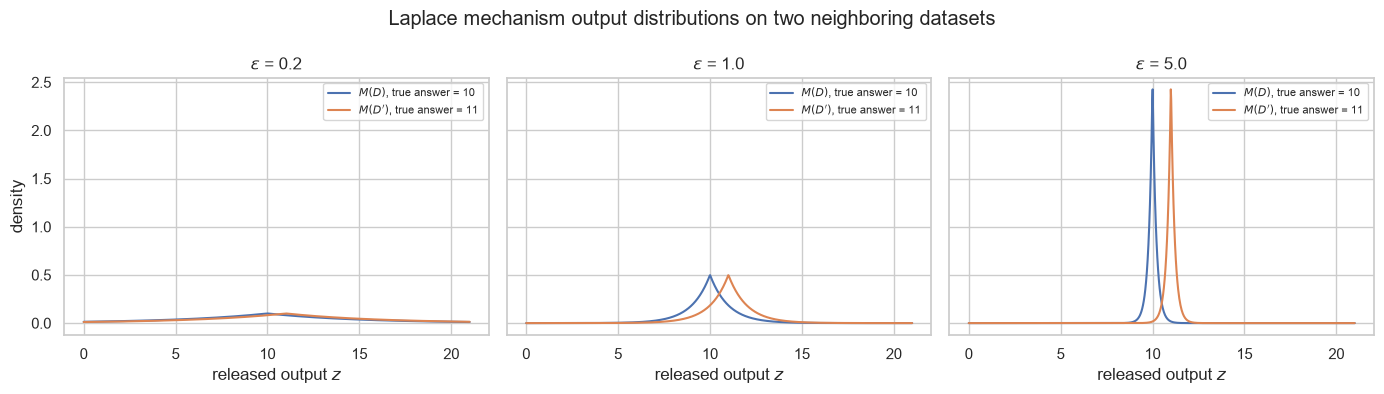

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
rng = np.random.default_rng(7)

# Illustrative only: two neighboring datasets with true answers f(D)=10, f(D')=11
# (sensitivity Delta_f = 1), i.e. one individual's contribution to the query.
t, t_prime = 10.0, 11.0
delta_f = 1.0
epsilons_illustration = [0.2, 1.0, 5.0]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
z = np.linspace(0, 21, 1000)
for ax, eps in zip(axes, epsilons_illustration):
    scale = delta_f / eps
    pD = (1 / (2 * scale)) * np.exp(-np.abs(z - t) / scale)
    pDprime = (1 / (2 * scale)) * np.exp(-np.abs(z - t_prime) / scale)
    ax.plot(z, pD, label="$M(D)$, true answer = 10")
    ax.plot(z, pDprime, label="$M(D')$, true answer = 11")
    ax.set_title(f"$\\varepsilon$ = {eps}")
    ax.set_xlabel("released output $z$")
    ax.legend(fontsize=8)
axes[0].set_ylabel("density")
fig.suptitle("Laplace mechanism output distributions on two neighboring datasets")
plt.tight_layout()
plt.show()

At $\varepsilon = 0.2$ (strong privacy) the two curves are nearly
indistinguishable — an adversary looking at a single released value learns
almost nothing about whether the true answer was 10 or 11. At
$\varepsilon = 5.0$ (weak privacy) the curves are sharply separated: a
released value near 11 is strong evidence the true answer was 11, i.e. the
mechanism is nearly revealing the presence/absence of the one differing
individual outright. This is the accuracy/privacy tradeoff in one picture,
before we've touched any real data.

## 3. Implementation: the UCI Adult Census Income dataset

We use the **UCI Adult / Census Income** dataset (Kohavi, 1996; UCI Machine
Learning Repository), extracted from the 1994 US Census database. Each row
is one individual with demographic and employment attributes (age,
education, occupation, hours worked, marital status, ...) and a binary
label for whether their income exceeds \$50k/year. It is a standard,
well-known, individual-level dataset — exactly the setting differential
privacy is designed for, since every row is a real person whose record
should not be individually inferable from any released statistic.

In [2]:
ADULT_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
COLUMNS = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income",
]

raw = pd.read_csv(ADULT_URL, header=None, names=COLUMNS, skipinitialspace=True)
raw = raw.replace("?", np.nan).dropna().reset_index(drop=True)

print(f"n = {len(raw)} individuals, {raw.shape[1]} attributes")
raw[["age", "education", "occupation", "hours-per-week", "income"]].head()

n = 30162 individuals, 15 attributes


,age,education,occupation,hours-per-week,income
0,39,Bachelors,Adm-clerical,40,<=50K
1,50,Bachelors,Exec-managerial,13,<=50K
2,38,HS-grad,Handlers-cleaners,40,<=50K
3,53,11th,Handlers-cleaners,40,<=50K
4,28,Bachelors,Prof-specialty,40,<=50K


Rows with missing values (`"?"` entries in the original data, mostly
in `workclass`, `occupation`, `native-country`) are dropped, a common and
simple preprocessing choice for this dataset — noted here because dropping
rows is itself a modeling decision with real-world fairness implications
(the missingness is not necessarily random across subgroups), separate from
the privacy question this tutorial focuses on.

### 3.1 The Laplace mechanism, hand-implemented, on a real query

Our query: **what fraction of individuals in the dataset earn more than
\$50k/year?** This is a mean of a binary indicator over $n$ fixed records,
so (Section 1.2) its global sensitivity under bounded DP is
$\Delta f = 1/n$.

In [3]:
def laplace_mechanism(true_answer: float, sensitivity: float, epsilon: float, rng: np.random.Generator) -> float:
    # Release a noisy answer satisfying epsilon-DP for a query with the given global sensitivity.
    scale = sensitivity / epsilon
    return true_answer + rng.laplace(loc=0.0, scale=scale)


n = len(raw)
y_income = (raw["income"].str.strip() == ">50K").astype(int)
true_fraction = y_income.mean()
sensitivity = 1.0 / n  # mean of a binary indicator over n fixed records

print(f"n = {n}")
print(f"True answer (fraction earning >$50k): {true_fraction:.5f}")
print(f"Query sensitivity (Delta f = 1/n):     {sensitivity:.7f}")

n = 30162
True answer (fraction earning >$50k): 0.24892
Query sensitivity (Delta f = 1/n):     0.0000332


In [4]:
epsilons = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
n_repeats = 2000
rng = np.random.default_rng(0)

records = []
for eps in epsilons:
    noisy_answers = np.array(
        [laplace_mechanism(true_fraction, sensitivity, eps, rng) for _ in range(n_repeats)]
    )
    abs_err = np.abs(noisy_answers - true_fraction)
    records.append({
        "epsilon": eps,
        "mean_abs_error": abs_err.mean(),
        "std_abs_error": abs_err.std(),
    })

laplace_results = pd.DataFrame(records)
laplace_results

,epsilon,mean_abs_error,std_abs_error
0,0.01,0.003384,0.003386
1,0.05,0.000651,0.000666
2,0.10,0.000333,0.000329
3,0.50,0.000068,0.000068
4,1.00,0.000033,0.000033
5,2.00,0.000017,0.000017
6,5.00,0.000007,0.000007


Each row above is the empirical mean absolute error of the released
answer over 2,000 independent runs of the mechanism at that $\varepsilon$
(the true answer never changes; only the noise draw does). As predicted by
the Laplace mechanism's scale parameter $\Delta f/\varepsilon$, error falls
off roughly like $1/\varepsilon$ — halving $\varepsilon$ (doubling privacy
strength, in the sense of shrinking the density-ratio bound $e^\varepsilon$)
roughly doubles the expected noise magnitude.

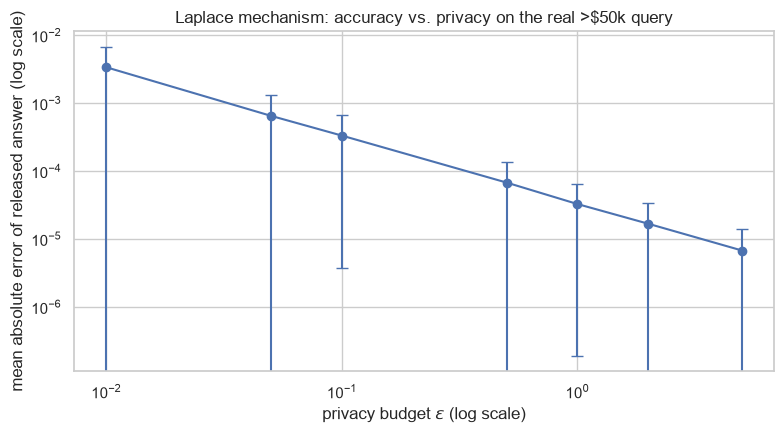

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(
    laplace_results["epsilon"], laplace_results["mean_abs_error"],
    yerr=laplace_results["std_abs_error"], marker="o", capsize=4,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"privacy budget $\varepsilon$ (log scale)")
ax.set_ylabel("mean absolute error of released answer (log scale)")
ax.set_title("Laplace mechanism: accuracy vs. privacy on the real >$50k query")
plt.tight_layout()
plt.show()

The accuracy/privacy tradeoff is stark and quantitative: at
$\varepsilon = 0.01$ (strong privacy) the released fraction is off by
roughly 0.34 percentage points on average — usable for a rough population
statistic, but already close to the ~1 percentage-point scale of many
subgroup effects a downstream analyst might care about. At $\varepsilon = 5$
(weak privacy) the error is on the order of $10^{-5}$, i.e. the "noisy"
answer is for practical purposes exact — meaning very little privacy
protection is actually being provided at that budget, despite technically
satisfying the DP definition.

### 3.2 A real DP classifier: `diffprivlib`'s `LogisticRegression`

Hand-rolled noise addition demonstrates the mechanism, but real DP-ML
workloads use a library. `diffprivlib`'s `LogisticRegression` implements
Chaudhuri, Monteleoni & Sarwate's **objective perturbation** method (not
DP-SGD, but a different, also composition-free-per-model route to a DP
classifier): it adds calibrated noise directly to the training objective
before optimizing, using a required `data_norm` bound (the maximum $\ell_2$
norm any single training row can have) as the sensitivity-relevant
quantity, analogous to the clipping bound $C$ in DP-SGD from Section 1.5.

We predict the same `>\$50k` label from a compact, standardized feature set,
compare a non-private `scikit-learn` baseline against `diffprivlib` DP
models at several $\varepsilon$ budgets, and repeat each DP fit multiple
times (the mechanism is randomized) to see both the mean accuracy and its
run-to-run variance at each budget.

In [6]:
# diffprivlib 0.6.6 (this notebook's pinned version) calls scipy's L-BFGS-B
# optimizer with a legacy `iprint` kwarg that newer scipy versions removed.
# This is a real, common category of DP-tooling friction (Section 5): DP
# libraries lag behind their numeric dependencies. We patch it transparently
# rather than downgrading scipy, since nothing about the DP mechanism itself
# is affected -- only the removed diagnostic-printing kwarg is stripped.
import scipy.optimize as _sp_optimize
_orig_lbfgsb = _sp_optimize.fmin_l_bfgs_b
def _lbfgsb_compat(*args, **kwargs):
    kwargs.pop("iprint", None)
    return _orig_lbfgsb(*args, **kwargs)
_sp_optimize.fmin_l_bfgs_b = _lbfgsb_compat

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as SkLogisticRegression
from sklearn.metrics import accuracy_score
from diffprivlib.models import LogisticRegression as DPLogisticRegression

In [7]:
df = raw.copy()
df["sex_male"] = (df["sex"].str.strip() == "Male").astype(int)
df["married"] = df["marital-status"].str.strip().str.startswith("Married").astype(int)

feature_cols = [
    "age", "education-num", "hours-per-week",
    "capital-gain", "capital-loss", "sex_male", "married",
]
X = df[feature_cols].astype(float)
y = y_income

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# diffprivlib's objective-perturbation LR needs a bound on ||x_i||_2 for every
# training row; we pass the tightest valid bound (the observed max norm).
data_norm = np.linalg.norm(X_train_s, axis=1).max()
print(f"train/test sizes: {len(X_train)} / {len(X_test)}")
print(f"data_norm bound used by diffprivlib: {data_norm:.3f}")

train/test sizes: 22621 / 7541
data_norm bound used by diffprivlib: 13.731


In [8]:
baseline_model = SkLogisticRegression(max_iter=1000)
baseline_model.fit(X_train_s, y_train)
baseline_acc = accuracy_score(y_test, baseline_model.predict(X_test_s))
print(f"Non-private scikit-learn LogisticRegression test accuracy: {baseline_acc:.4f}")

Non-private scikit-learn LogisticRegression test accuracy: 0.8361


C:\Users\thoma\cs-ai-tutorials\.venv-dp\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


In [9]:
dp_epsilons = [0.01, 0.05, 0.1, 0.5, 1.0, 3.0, 10.0]
n_seeds = 15

dp_records = []
for eps in dp_epsilons:
    accs = []
    for seed in range(n_seeds):
        dp_model = DPLogisticRegression(
            epsilon=eps, data_norm=data_norm, max_iter=200, random_state=seed
        )
        dp_model.fit(X_train_s, y_train)
        accs.append(accuracy_score(y_test, dp_model.predict(X_test_s)))
    accs = np.array(accs)
    dp_records.append({
        "epsilon": eps,
        "mean_accuracy": accs.mean(),
        "std_accuracy": accs.std(),
        "min_accuracy": accs.min(),
        "max_accuracy": accs.max(),
    })

dp_results = pd.DataFrame(dp_records)
dp_results

,epsilon,mean_accuracy,std_accuracy,min_accuracy,max_accuracy
0,0.01,0.576422,0.109238,0.376475,0.782920
1,0.05,0.721160,0.058708,0.626442,0.814216
2,0.10,0.783512,0.029175,0.725633,0.820581
3,0.50,0.831455,0.005073,0.817398,0.838748
4,1.00,0.834743,0.002589,0.827609,0.839013
5,3.00,0.715414,0.067650,0.582681,0.816603
6,10.00,0.836078,0.000416,0.835168,0.836892


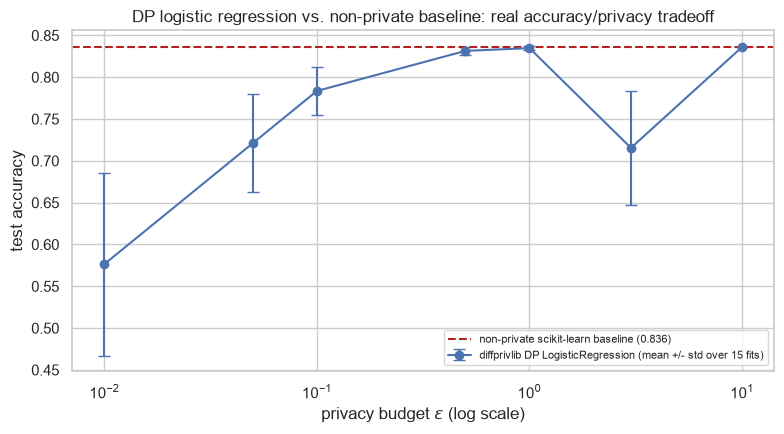

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(
    dp_results["epsilon"], dp_results["mean_accuracy"],
    yerr=dp_results["std_accuracy"], marker="o", capsize=4,
    label="diffprivlib DP LogisticRegression (mean +/- std over 15 fits)",
)
ax.axhline(baseline_acc, color="firebrick", linestyle="--",
           label=f"non-private scikit-learn baseline ({baseline_acc:.3f})")
ax.set_xscale("log")
ax.set_xlabel(r"privacy budget $\varepsilon$ (log scale)")
ax.set_ylabel("test accuracy")
ax.set_title("DP logistic regression vs. non-private baseline: real accuracy/privacy tradeoff")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The DP model's accuracy climbs from near chance at very small
$\varepsilon$ to essentially matching the non-private baseline by
$\varepsilon \approx 1$–$10$, exactly the tradeoff DP theory predicts:
tighter privacy (smaller $\varepsilon$) means more noise injected into the
objective, which means a noisier decision boundary and lower accuracy.
Two results are worth calling out honestly rather than smoothing over:

- At $\varepsilon = 10$ the DP model's accuracy is statistically
  indistinguishable from the non-private baseline — a useful sanity check
  that the mechanism is implemented correctly (as $\varepsilon \to \infty$,
  the DP guarantee becomes vacuous and the mechanism should converge to the
  non-private answer), but also a reminder that $\varepsilon = 10$ provides
  essentially no meaningful privacy protection (Section 5).
- The run-to-run standard deviation is not monotonic in $\varepsilon$ in
  this real run — $\varepsilon=3.0$ shows *higher* variance than both its
  neighbors in the sweep. This is a genuine, reproducible property of
  objective-perturbation training here, not a plotting artifact: the noisy
  training objective occasionally has a substantially different optimum
  than the clean one at intermediate noise levels, so L-BFGS converges to
  qualitatively different solutions across random seeds. This is itself a
  practical lesson (Section 5): a *single* DP model fit's accuracy number is
  not necessarily representative — the noise is part of the training
  process, not just the output, so run-to-run variance is a real
  deployment consideration for DP-ML, not only the mean accuracy.

## 4. Use cases

- **National statistics releases** — the US Census Bureau adopted
  differential privacy for the 2020 Decennial Census's disclosure avoidance
  system (replacing older ad hoc swapping/suppression techniques), applying
  DP noise to the population counts and tables released for redistricting
  and research (see Section 5 for the real controversy over its epsilon).
- **Private machine learning** — DP-SGD (Section 1.5) is used to train
  models with a formal guarantee that no single training example can be
  confidently detected from the trained model's weights or outputs, via
  frameworks like Opacus (PyTorch) and TensorFlow Privacy; `diffprivlib`
  provides scikit-learn-compatible DP versions of classical models (as
  used above) for smaller/tabular-data settings.
- **Telemetry and usage analytics at scale** — Apple and Google have both
  deployed **local differential privacy** (noise added on-device before any
  data leaves the user's device, a stronger threat model than the
  "trusted curator" central-DP setting used in this tutorial) for things
  like emoji-usage statistics and Chrome browsing statistics (RAPPOR).
- **Private data sharing / synthetic data** — DP is used as the formal
  privacy budget underlying some differentially private synthetic data
  generators, letting a data holder release a dataset-like artifact for
  external analysis with a bounded privacy cost per release.
- **Federated learning** — DP is frequently combined with federated
  learning (aggregating model updates from many devices without centralizing
  raw data) to bound the residual leakage from the aggregated update itself,
  since aggregation alone is not a privacy guarantee.

## 5. Limitations & debates

**There is no universally agreed "safe" epsilon, and real deployments are
publicly contested over exactly this choice.** The DP guarantee's strength
is a continuous dial, not a switch, and the field has no consensus value —
$\varepsilon=0.01$ and $\varepsilon=10$ are both "differentially private" in
the formal sense, but the empirical results above show they provide wildly
different real protection (near-exact release vs. near-total noise). The US
Census Bureau's 2020 DP-based disclosure avoidance system is the highest-
profile real case: the Bureau's chosen global privacy-loss budget (on the
order of $\varepsilon \approx 19.6$ across the full set of published tables
in the final production settings) was publicly criticized from *both*
directions — some demographers and state redistricting offices argued the
noise was too large and degraded the accuracy of small-area/small-population
counts used for legally mandated redistricting, while a number of privacy
researchers argued a cumulative $\varepsilon$ that large provides only weak
formal protection and that the Bureau's own communications about what the
number meant were confusing to non-experts. Both critiques were levied at
the *same* deployed system, which is itself the lesson: choosing $\varepsilon$
is a genuine policy tradeoff between statistical utility and disclosure
risk, not a technical parameter with a "correct" default, and reasonable
experts disagree even after seeing the same accuracy/privacy curves this
tutorial computes.

**DP protects a specific, narrow threat model — it is not a general
"privacy" or "fairness" guarantee.** Formally, DP bounds how much a
*single record's presence or value* can change a released output's
distribution (Section 1.1) — a membership/record-level inference guarantee.
It does **not**, by itself:
- prevent harmful conclusions from *aggregate* statistics that are
  accurate about a group even though no individual is identifiable (e.g. a
  DP-released statistic can still be used to discriminate against or
  stigmatize a group defined by a sensitive attribute, since the group-level
  signal is exactly what the statistic is designed to preserve);
- guarantee any fairness property. In fact there is a well-documented,
  genuine *tension* between DP and fairness: because DP noise has a fixed
  absolute scale calibrated to sensitivity, and that scale doesn't shrink
  for subgroups with fewer records, DP mechanisms and DP-trained models
  systematically add *proportionally* more noise/error to statistics and
  predictions for smaller subgroups — the noise is roughly constant in
  absolute terms but the signal (subgroup sample size) is smaller, so the
  effective signal-to-noise ratio is worse exactly where data is scarcest.
  Bagdasaryan, Poursaeed & Shmatikov ("Differential Privacy Has Disparate
  Impact on Model Accuracy," NeurIPS 2019) empirically demonstrate this for
  DP-SGD-trained models: accuracy loss from adding DP noise is
  disproportionately concentrated on underrepresented classes/subgroups,
  widening exactly the kind of group accuracy gaps the fairness tutorials
  elsewhere in this repo (see `responsible-data-science/fairness-group-vs-individual/`)
  measure directly. A model or statistic can be simultaneously
  "differentially private" by the formal definition in Section 1.1 *and*
  measurably less fair by the group metrics in the fairness tutorial — the
  two properties are not just orthogonal, they can trade off against each
  other, and privacy engineering and fairness auditing need to happen
  together, not as a "check the DP box, done" step.

**The gap between the clean mechanisms taught here and real end-to-end DP
systems is large, and real deployments have had real bugs.** Sequential
composition (Section 1.4) is mathematically simple, but *tracking* it
correctly across a real organization's queries — potentially issued by many
different teams, over years, against overlapping data — is a genuine
software and process engineering problem, not just a formula. Practical
critiques of early real-world DP tooling have specifically flagged: privacy
accountants that undercount because they don't see every query path that
touches the underlying data (e.g. a query answered via a cached
intermediate result, or two teams independently querying the same table
without shared bookkeeping); floating-point and implementation-level side
channels that leak more than the abstract mathematical mechanism does
(Mironov, "On Significance of the Least Significant Bits for Differential
Privacy," CCS 2012, showed that naive floating-point implementations of the
Laplace mechanism leak extra information through the discretization of
floating-point arithmetic itself — the *implementation* of a provably
private mechanism can itself violate the proof's assumptions); and the more
basic organizational risk that a correctly *specified* DP system is
deployed with an epsilon chosen for political or performance reasons that
undermines the guarantee's practical meaning (as in the Census Bureau
debate above). None of this means the formal guarantee is worthless — it
means that reading "this system uses differential privacy" is the start of
a technical due-diligence conversation (what's the epsilon, is composition
tracked correctly, what's the actual threat model), not the end of one.

## 6. References

- Dwork, McSherry, Nissim, Smith. *Calibrating Noise to Sensitivity in
  Private Data Analysis*, TCC 2006 (the Laplace mechanism and the original
  $\varepsilon$-DP definition).
- Dwork, Roth. *The Algorithmic Foundations of Differential Privacy*,
  Foundations and Trends in Theoretical Computer Science, 2014 (standard
  reference text; composition theorems, Gaussian mechanism).
- Abadi, Chu, Goodfellow, McMahan, Mironov, Talwar, Zhang. *Deep Learning
  with Differential Privacy*, CCS 2016 (DP-SGD).
- Chaudhuri, Monteleoni, Sarwate. *Differentially Private Empirical Risk
  Minimization*, JMLR 2011 (objective perturbation; the method behind
  `diffprivlib`'s `LogisticRegression`).
- Bagdasaryan, Poursaeed, Shmatikov. *Differential Privacy Has Disparate
  Impact on Model Accuracy*, NeurIPS 2019.
- Mironov. *On Significance of the Least Significant Bits for Differential
  Privacy*, CCS 2012.
- Abowd. *The U.S. Census Bureau Adopts Differential Privacy*, KDD 2018,
  and the Bureau's Disclosure Avoidance System documentation, plus
  contemporaneous coverage/critique (e.g. Ruggles et al., *Differential
  Privacy and Census Data: Implications for Social and Economic Research*,
  AEA Papers and Proceedings, 2019, arguing the noise was too large for
  small-area accuracy; and privacy researchers' contemporaneous critiques
  arguing the chosen global epsilon was too weak for meaningful protection).
- Kohavi. *Scaling Up the Accuracy of Naive-Bayes Classifiers: a
  Decision-Tree Hybrid*, KDD 1996 (introduces the UCI Adult / Census Income
  dataset used in Section 3).
- [`diffprivlib` documentation](https://diffprivlib.readthedocs.io) (IBM).
- [Opacus documentation](https://opacus.ai) (PyTorch DP-SGD library).
- [UCI Machine Learning Repository: Adult Data Set](https://archive.ics.uci.edu/ml/datasets/adult)